In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df=pd.read_csv(r'C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\feature_engineered_data.csv')

In [3]:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')

In [4]:
import os
import copy
import joblib
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

os.makedirs("models", exist_ok=True)

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

target_col = "load"
SEQ_LEN = 744
HORIZON = 744   # max future horizon for saved LSTM

df = df.copy()
df["Post_Break"] = (df.index >= "2024-07-01").astype(int)

lstm_feature_cols = [
    'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_std_24',
    'rolling_mean_48', 'rolling_std_48',
    'rolling_mean_168', 'rolling_std_168',
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
]

# ============================================================
# MODEL
# ============================================================
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3, output_size=744):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def make_sequences(data_x, data_y, seq_len, horizon):
    X, y = [], []
    max_i = len(data_x) - seq_len - horizon + 1

    for i in range(max_i):
        X.append(data_x[i:i + seq_len])
        y.append(data_y[i + seq_len:i + seq_len + horizon])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def train_lstm(
    X_tr, y_tr, input_size, horizon,
    epochs=100, batch_size=32,
    patience=10, min_delta=1e-4
):
    n = len(X_tr)
    split_idx = int(n * 0.85)

    X_train, X_val = X_tr[:split_idx], X_tr[split_idx:]
    y_train, y_val = y_tr[:split_idx], y_tr[split_idx:]

    model = LSTMForecaster(
        input_size=input_size,
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        output_size=horizon
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4
    )

    criterion = nn.MSELoss()

    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train),
        torch.tensor(y_train)
    )

    val_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_val),
        torch.tensor(y_val)
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    best_val_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            lr_now = optimizer.param_groups[0]["lr"]
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"lr={lr_now:.6f}"
            )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


# ============================================================
# FINAL TRAINING ON FULL AVAILABLE DATA
# ============================================================
train_df = df.dropna(subset=lstm_feature_cols + [target_col]).copy()

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(train_df[lstm_feature_cols].values)

y_scaled = scaler_y.fit_transform(
    train_df[target_col].values.reshape(-1, 1)
).ravel()

X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN, HORIZON)

print(f"Final LSTM training sequences: {len(X_seq)}")

lstm_final = train_lstm(
    X_seq,
    y_seq,
    input_size=len(lstm_feature_cols),
    horizon=HORIZON,
    epochs=100,
    batch_size=32,
    patience=10
)

# ============================================================
# SAVE MODEL + SCALERS + CONFIG
# ============================================================
torch.save(
    {
        "model_state_dict": lstm_final.state_dict(),
        "input_size": len(lstm_feature_cols),
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.3,
        "seq_len": SEQ_LEN,
        "horizon": HORIZON,
        "feature_cols": lstm_feature_cols,
    },
    "models/lstm_final.pth"
)

joblib.dump(scaler_x, "models/lstm_scaler_x.pkl")
joblib.dump(scaler_y, "models/lstm_scaler_y.pkl")
joblib.dump(lstm_feature_cols, "models/lstm_feature_cols.pkl")

print("Saved LSTM model to models/lstm_final.pth")
print("Saved LSTM scalers and feature columns.")

Using device: cuda
Final LSTM training sequences: 24649
Epoch 1/100 | train_loss=0.1904 | val_loss=0.2485 | lr=0.001000
Epoch 10/100 | train_loss=0.0258 | val_loss=0.2405 | lr=0.000500
Early stopping triggered at epoch 13
Saved LSTM model to models/lstm_final.pth
Saved LSTM scalers and feature columns.


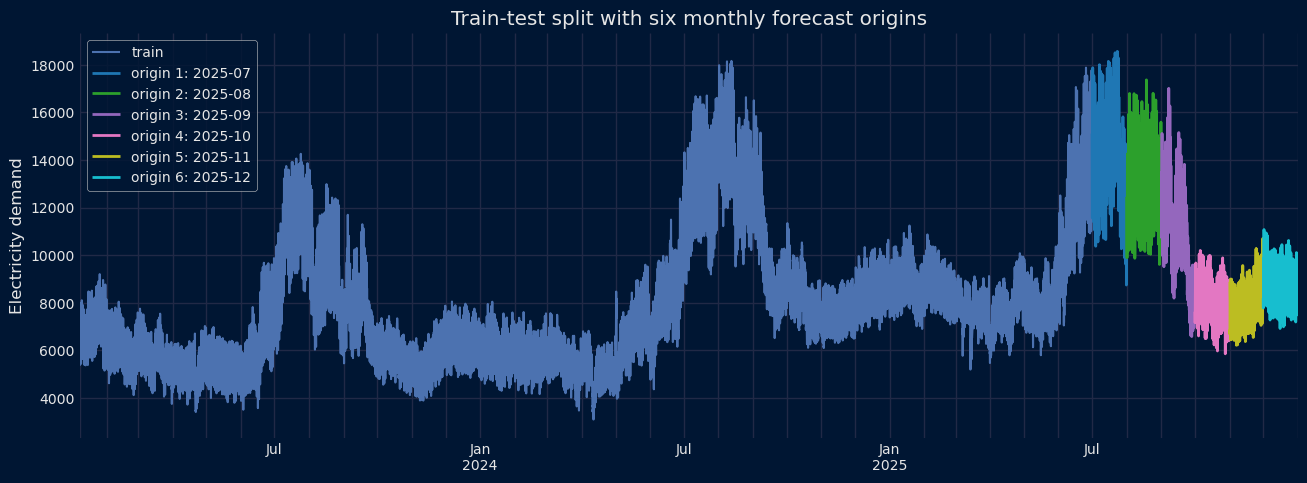

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from skforecast.plot import set_dark_theme

set_dark_theme()

target_col = "load"   # change this to your actual target column
end_train = "2025-06-30 23:00:00"

data_train = df.loc[:end_train].copy()
data_test = df.loc[end_train:].copy()

# Remove duplicated boundary timestamp from test
data_test = data_test.iloc[1:]

origins = sorted(data_test.index.to_period("M").unique())
colors = cm.tab10(np.linspace(0, 1, len(origins)))

fig, ax = plt.subplots(figsize=(14, 5))

data_train[target_col].plot(
    ax=ax,
    label="train",
    color="#4C72B0",
    linewidth=1.5
)

for i, origin in enumerate(origins):
    test_origin = data_test[data_test.index.to_period("M") == origin]

    test_origin[target_col].plot(
        ax=ax,
        label=f"origin {i+1}: {origin}",
        color=colors[i],
        linewidth=2
    )

ax.set_title("Train-test split with six monthly forecast origins")
ax.set_xlabel("")
ax.set_ylabel("Electricity demand")
ax.legend(loc="upper left")

plt.show()

Using device: cuda

Origin 1/6 — 2025-07-01
Forecast horizon: 744 hours
Training on 20809 sequences...
  Epoch 1/80 — train: 0.2450 — val: 0.2785
  Epoch 10/80 — train: 0.0514 — val: 0.1920
  Early stopping at epoch 14
  Done — 744 hours forecasted

Origin 2/6 — 2025-08-01
Forecast horizon: 744 hours
Training on 21553 sequences...
  Epoch 1/80 — train: 0.2022 — val: 0.3294
  Epoch 10/80 — train: 0.0438 — val: 0.2750
  Early stopping at epoch 11
  Done — 744 hours forecasted

Origin 3/6 — 2025-09-01
Forecast horizon: 720 hours
Training on 22321 sequences...
  Epoch 1/80 — train: 0.1864 — val: 0.3286
  Epoch 10/80 — train: 0.0374 — val: 0.3337
  Early stopping at epoch 13
  Done — 720 hours forecasted

Origin 4/6 — 2025-10-01
Forecast horizon: 744 hours
Training on 23017 sequences...
  Epoch 1/80 — train: 0.1801 — val: 0.3635
  Epoch 10/80 — train: 0.0412 — val: 0.3522
  Early stopping at epoch 16
  Done — 744 hours forecasted

Origin 5/6 — 2025-11-01
Forecast horizon: 720 hours
Training

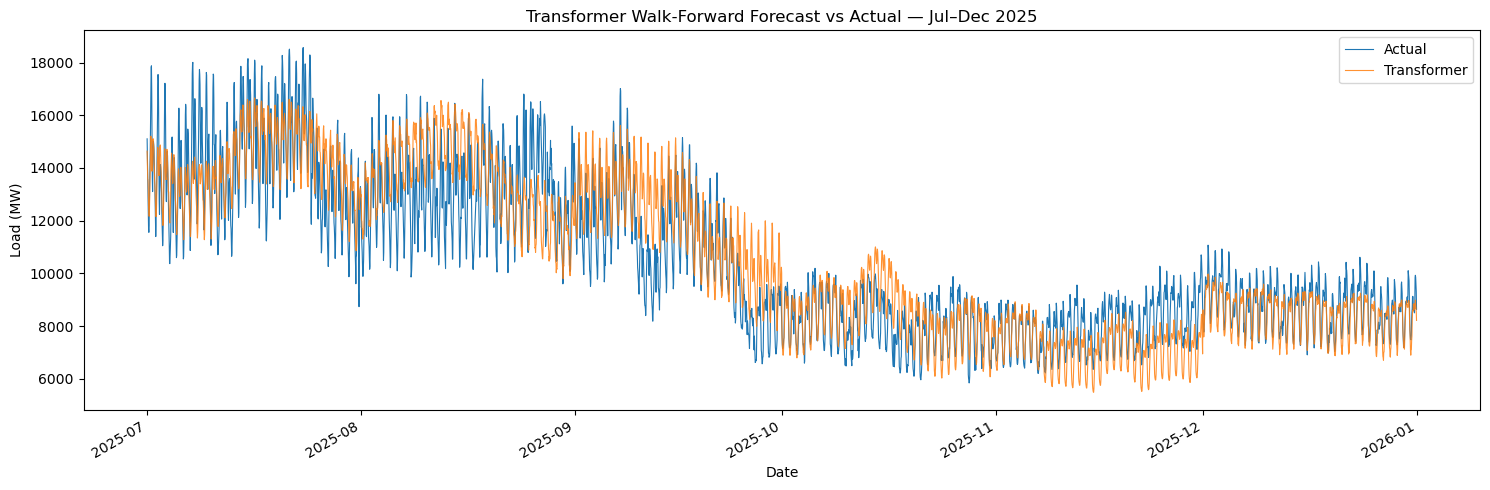

In [4]:
import copy
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 0) FEATURES
# ============================================================
df = df.copy()
df['Post_Break'] = (df.index >= '2024-07-01').astype(int)

feature_cols = [
    'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_std_24',
    'rolling_mean_48', 'rolling_std_48',
    'rolling_mean_168', 'rolling_std_168',
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
]
target_col = 'load'
SEQ_LEN = 168   # one month lookback

# ============================================================
# 1) POSITIONAL ENCODING
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# ============================================================
# 2) MODEL
# ============================================================
class TransformerForecaster(nn.Module):
    def __init__(
        self,
        input_size,
        output_size,
        d_model=32,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.encoder(x)
        x = self.norm(x[:, -1, :])
        return self.fc(x)

# ============================================================
# 3) SEQUENCE BUILDER
# ============================================================
def make_sequences(data_x, data_y, seq_len, horizon):
    X, y = [], []
    max_i = len(data_x) - seq_len - horizon + 1
    for i in range(max_i):
        X.append(data_x[i:i+seq_len])
        y.append(data_y[i+seq_len:i+seq_len+horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# ============================================================
# 4) TRAIN
# ============================================================
def train_transformer(
    X_tr, y_tr, input_size, horizon,
    epochs=80, batch_size=32, patience=8
):
    n = len(X_tr)
    split_idx = int(n * 0.85)

    X_train, X_val = X_tr[:split_idx], X_tr[split_idx:]
    y_train, y_val = y_tr[:split_idx], y_tr[split_idx:]

    model = TransformerForecaster(
        input_size=input_size,
        output_size=horizon,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )
    criterion = nn.MSELoss()

    train_ds = torch.utils.data.TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    val_ds   = torch.utils.data.TensorDataset(torch.tensor(X_val), torch.tensor(y_val))

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    best_val = np.inf
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{epochs} — train: {train_loss:.4f} — val: {val_loss:.4f}")

        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ============================================================
# 5) WALK-FORWARD
# ============================================================
origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_tf = []
actuals_tf = []

for i, origin in enumerate(origins):
    print(f"\n{'='*60}")
    print(f"Origin {i+1}/6 — {origin.date()}")

    month_end = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
    horizon = len(df.loc[origin:month_end])
    print(f"Forecast horizon: {horizon} hours")

    train_df = df.loc[: origin - pd.Timedelta(hours=1)].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    X_scaled = scaler_x.fit_transform(train_df[feature_cols].values)
    y_scaled = scaler_y.fit_transform(train_df[target_col].values.reshape(-1, 1)).ravel()

    X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN, horizon)
    print(f"Training on {len(X_seq)} sequences...")

    model = train_transformer(
        X_seq, y_seq,
        input_size=len(feature_cols),
        horizon=horizon,
        epochs=80,
        batch_size=32,
        patience=8
    )

    model.eval()
    with torch.no_grad():
        window = df.loc[
            origin - pd.Timedelta(hours=SEQ_LEN): origin - pd.Timedelta(hours=1)
        ].dropna(subset=feature_cols)

        x_in = scaler_x.transform(window[feature_cols].values)
        x_in = torch.tensor(x_in[np.newaxis], dtype=torch.float32).to(device)

        pred_scaled = model(x_in).cpu().numpy().ravel()
        pred_mw = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

    actual_month = df.loc[origin:month_end, target_col]
    pred_series = pd.Series(pred_mw[:len(actual_month)], index=actual_month.index)

    preds_tf.append(pred_series)
    actuals_tf.append(actual_month)

    print(f"  Done — {len(actual_month)} hours forecasted")

# ============================================================
# 6) METRICS
# ============================================================
pred_tf = pd.concat(preds_tf).sort_index()
actual_tf = pd.concat(actuals_tf).sort_index()

mae  = np.mean(np.abs(actual_tf - pred_tf))
rmse = np.sqrt(np.mean((actual_tf - pred_tf) ** 2))
mape = np.mean(np.abs((actual_tf - pred_tf) / actual_tf)) * 100

print(f"\nTransformer Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 7) PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_tf.index, actual_tf.values, label="Actual", linewidth=0.8)
ax.plot(pred_tf.index, pred_tf.values, label="Transformer", linewidth=0.8, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("Transformer Walk-Forward Forecast vs Actual — Jul–Dec 2025")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ============================================================


In [4]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [6]:
import copy
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 0) FEATURES
# ============================================================
df = df.copy()
df['Post_Break'] = (df.index >= '2024-07-01').astype(int)

feature_cols = [
    'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_std_24',
    'rolling_mean_48', 'rolling_std_48',
    'rolling_mean_168', 'rolling_std_168',
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    
]
target_col = 'load'

# one month lookback
SEQ_LEN = 744

# ============================================================
# 1) MODEL
# ============================================================
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3, output_size=744):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# ============================================================
# 2) SEQUENCE BUILDER
# ============================================================
def make_sequences(data_x, data_y, seq_len, horizon):
    X, y = [], []
    max_i = len(data_x) - seq_len - horizon + 1
    for i in range(max_i):
        X.append(data_x[i : i + seq_len])
        y.append(data_y[i + seq_len : i + seq_len + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# ============================================================
# 3) TRAINING FUNCTION WITH VALIDATION + EARLY STOPPING
# ============================================================
def train_lstm(
    X_tr, y_tr, input_size, horizon,
    epochs=100, batch_size=32,
    patience=10, min_delta=1e-4
):
    # chronological split: last 15% for validation
    n = len(X_tr)
    split_idx = int(n * 0.85)

    X_train, X_val = X_tr[:split_idx], X_tr[split_idx:]
    y_train, y_val = y_tr[:split_idx], y_tr[split_idx:]

    model = LSTMForecaster(
        input_size=input_size,
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        output_size=horizon
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4
    )
    criterion = nn.MSELoss()

    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train), torch.tensor(y_train)
    )
    val_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_val), torch.tensor(y_val)
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    val_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False
    )

    best_val_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(epochs):
        # -------------------------
        # training
        # -------------------------
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # -------------------------
        # validation
        # -------------------------
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(
                f"  Epoch {epoch+1}/{epochs} — "
                f"train_loss: {train_loss:.4f} — "
                f"val_loss: {val_loss:.4f} — "
                f"lr: {lr_now:.6f}"
            )

        # early stopping
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping triggered at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ============================================================
# 4) WALK-FORWARD LOOP (MONTHLY OUTPUT)
# ============================================================
origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_lstm = []
actuals_lstm = []

for i, origin in enumerate(origins):
    print(f"\n{'='*60}")
    print(f"Origin {i+1}/6 — {origin.date()}")

    month_end = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
    horizon = len(df.loc[origin:month_end])
    print(f"Forecast horizon: {horizon} hours")

    # training data up to the hour before origin
    train_df = df.loc[: origin - pd.Timedelta(hours=1)].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    # scale using training only
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    X_scaled = scaler_x.fit_transform(train_df[feature_cols].values)
    y_scaled = scaler_y.fit_transform(
        train_df[target_col].values.reshape(-1, 1)
    ).ravel()

    # build training sequences
    X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN, horizon)
    print(f"Training on {len(X_seq)} sequences...")

    model = train_lstm(
        X_seq, y_seq,
        input_size=len(feature_cols),
        horizon=horizon,
        epochs=100,
        batch_size=32,
        patience=10
    )

    # forecast using the last SEQ_LEN real hours before origin
    model.eval()
    with torch.no_grad():
        window = df.loc[
            origin - pd.Timedelta(hours=SEQ_LEN) : origin - pd.Timedelta(hours=1)
        ].dropna(subset=feature_cols)

        x_in = scaler_x.transform(window[feature_cols].values)
        x_in = torch.tensor(x_in[np.newaxis], dtype=torch.float32).to(device)

        pred_scaled = model(x_in).cpu().numpy().ravel()
        pred_mw = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

    actual_month = df.loc[origin:month_end, target_col]
    pred_series = pd.Series(pred_mw[:len(actual_month)], index=actual_month.index)

    preds_lstm.append(pred_series)
    actuals_lstm.append(actual_month)

    print(f"  Done — {len(actual_month)} hours forecasted")

# ============================================================
# 5) METRICS
# ============================================================
pred_lstm = pd.concat(preds_lstm).sort_index()
actual_lstm = pd.concat(actuals_lstm).sort_index()

mae  = np.mean(np.abs(actual_lstm - pred_lstm))
rmse = np.sqrt(np.mean((actual_lstm - pred_lstm) ** 2))
mape = np.mean(np.abs((actual_lstm - pred_lstm) / actual_lstm)) * 100

print(f"\nOptimized LSTM Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

Using device: cuda

Origin 1/6 — 2025-07-01
Forecast horizon: 744 hours
Training on 20233 sequences...
  Epoch 1/100 — train_loss: 0.2374 — val_loss: 0.3104 — lr: 0.001000
  Epoch 10/100 — train_loss: 0.0299 — val_loss: 0.5064 — lr: 0.000500
  Early stopping triggered at epoch 11
  Done — 744 hours forecasted

Origin 2/6 — 2025-08-01
Forecast horizon: 744 hours
Training on 20977 sequences...
  Epoch 1/100 — train_loss: 0.1821 — val_loss: 0.3948 — lr: 0.001000
  Epoch 10/100 — train_loss: 0.0258 — val_loss: 0.2747 — lr: 0.001000
  Epoch 20/100 — train_loss: 0.0173 — val_loss: 0.2831 — lr: 0.000500
  Early stopping triggered at epoch 26
  Done — 744 hours forecasted

Origin 3/6 — 2025-09-01
Forecast horizon: 720 hours
Training on 21745 sequences...
  Epoch 1/100 — train_loss: 0.1575 — val_loss: 0.3225 — lr: 0.001000
  Epoch 10/100 — train_loss: 0.0247 — val_loss: 0.3261 — lr: 0.001000
  Early stopping triggered at epoch 18
  Done — 720 hours forecasted

Origin 4/6 — 2025-10-01
Forecast h

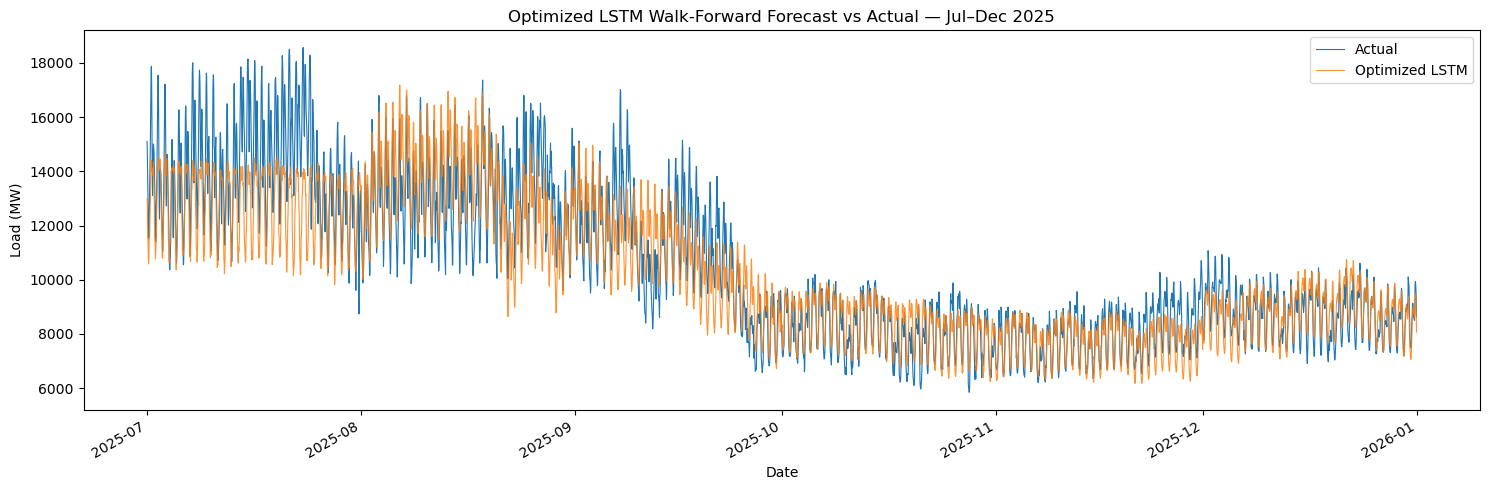

🏃 View run Optimized_LSTM_monthly_output at: http://127.0.0.1:5000/#/experiments/4/runs/9931e4cfb87146b89c838c678ac60cdb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [9]:
# ============================================================
# 6) PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_lstm.index, actual_lstm.values, label="Actual", linewidth=0.8)
ax.plot(pred_lstm.index, pred_lstm.values, label="Optimized LSTM", linewidth=0.8, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("Optimized LSTM Walk-Forward Forecast vs Actual — Jul–Dec 2025")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ============================================================
# 7) MLFLOW LOGGING
# ============================================================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Load_Forecasting")

with mlflow.start_run(run_name="Optimized_LSTM_monthly_output"):
    mlflow.log_param("model", "LSTM")
    mlflow.log_param("forecast_horizon", "monthly_direct_output")
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_param("seq_len", SEQ_LEN)
    mlflow.log_param("features", str(feature_cols))
    mlflow.log_param("hidden_size", 128)
    mlflow.log_param("num_layers", 2)
    mlflow.log_param("dropout", 0.3)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("max_epochs", 100)
    mlflow.log_param("patience", 10)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 1e-3)
    mlflow.log_param("scheduler", "ReduceLROnPlateau")
    mlflow.log_param("gradient_clipping", 1.0)
    mlflow.log_param("post_break_feature", True)

    mlflow.log_metric("MAE", float(mae))
    mlflow.log_metric("RMSE", float(rmse))
    mlflow.log_metric("MAPE", float(mape))

    fig.savefig("optimized_lstm_forecast.png")
    mlflow.log_artifact("optimized_lstm_forecast.png")

In [5]:

feature_cols = [
    'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_std_24',
    'rolling_mean_48', 'rolling_std_48',
    'rolling_mean_168', 'rolling_std_168',
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'hour', 'day_of_week', 'month', 'year'
]
target_col = 'load'
SEQ_LEN    = 336   # one week lookback window

# ── 1. Model ──────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=128,
                 num_layers=2, dropout=0.2, output_size=744):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# ── 2. Sequence builder ───────────────────────────────────────
def make_sequences(data_x, data_y, seq_len, horizon):
    X, y = [], []
    for i in range(len(data_x) - seq_len - horizon):
        X.append(data_x[i : i + seq_len])
        y.append(data_y[i + seq_len : i + seq_len + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# ── 3. Training function ──────────────────────────────────────
def train_lstm(X_tr, y_tr, input_size, horizon, epochs=50, batch_size=64):
    model     = LSTMForecaster(input_size=input_size, output_size=horizon).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_tr), torch.tensor(y_tr)
    )
    loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=False  # no shuffle for time series
    )

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in loader:
            xb, yb     = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs} — loss: {total_loss/len(loader):.4f}")
    return model

# ── 4. Walk-forward loop ──────────────────────────────────────
origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_lstm   = []
actuals_lstm = []

for i, origin in enumerate(origins):
    print(f"\n{'='*50}")
    print(f"Origin {i+1}/6 — {origin.date()}")

    # how many hours in this month
    month_end = origin + pd.offsets.MonthEnd(0)
    horizon   = int((month_end - origin).total_seconds() / 3600) + 1
    print(f"Forecast horizon: {horizon} hours")

    # training data: everything before this month
    train_df = df.loc[: origin - pd.Timedelta(hours=1)].dropna()

    # scale on training data only
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    X_scaled = scaler_x.fit_transform(train_df[feature_cols].values)
    y_scaled = scaler_y.fit_transform(
        train_df[target_col].values.reshape(-1, 1)
    ).ravel()

    # build sequences and train
    X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN, horizon)
    print(f"Training on {len(X_seq)} sequences...")
    model = train_lstm(X_seq, y_seq, input_size=len(feature_cols), horizon=horizon)

    # forecast: feed last SEQ_LEN real hours before origin
    model.eval()
    with torch.no_grad():
        window   = df.loc[
            origin - pd.Timedelta(hours=SEQ_LEN) : origin - pd.Timedelta(hours=1)
        ]
        x_in     = scaler_x.transform(window[feature_cols].values)
        x_in     = torch.tensor(x_in[np.newaxis], dtype=torch.float32).to(device)

        pred_scaled = model(x_in).cpu().numpy().ravel()
        pred_mw     = scaler_y.inverse_transform(
            pred_scaled.reshape(-1, 1)
        ).ravel()

    # align predictions with actual index
    actual_month = df.loc[origin : month_end, target_col]
    pred_series  = pd.Series(pred_mw[:len(actual_month)], index=actual_month.index)

    preds_lstm.append(pred_series)
    actuals_lstm.append(actual_month)
    print(f"  Done — {len(actual_month)} hours forecasted")

# ── 5. Metrics ────────────────────────────────────────────────
pred_lstm   = pd.concat(preds_lstm).sort_index()
actual_lstm = pd.concat(actuals_lstm).sort_index()

mae  = np.mean(np.abs(actual_lstm - pred_lstm))
rmse = np.sqrt(np.mean((actual_lstm - pred_lstm)**2))
mape = np.mean(np.abs((actual_lstm - pred_lstm) / actual_lstm)) * 100

print(f"\nLSTM Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")


Origin 1/6 — 2025-07-01
Forecast horizon: 721 hours
Training on 20663 sequences...


KeyboardInterrupt: 

In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp").sort_index()

In [8]:
y = df["load"].copy()

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda



Monthly refit 1/6 — 2025-07-01
Training on 21385 sequences...
  Epoch 10/50 — loss: 0.1333
  Epoch 20/50 — loss: 0.0850
  Epoch 30/50 — loss: 0.0792
  Epoch 40/50 — loss: 0.0647
  Epoch 50/50 — loss: 0.0563
  Week 2025-07-01 forecasted — 168 hours
  Week 2025-07-08 forecasted — 168 hours
  Week 2025-07-15 forecasted — 168 hours
  Week 2025-07-22 forecasted — 168 hours
  Week 2025-07-29 forecasted — 168 hours

Monthly refit 2/6 — 2025-08-01
Training on 22129 sequences...
  Epoch 10/50 — loss: 0.2113
  Epoch 20/50 — loss: 0.1045
  Epoch 30/50 — loss: 0.0828
  Epoch 40/50 — loss: 0.0703
  Epoch 50/50 — loss: 0.0839
  Week 2025-08-01 forecasted — 168 hours
  Week 2025-08-08 forecasted — 168 hours
  Week 2025-08-15 forecasted — 168 hours
  Week 2025-08-22 forecasted — 168 hours
  Week 2025-08-29 forecasted — 168 hours

Monthly refit 3/6 — 2025-09-01
Training on 22873 sequences...
  Epoch 10/50 — loss: 0.1259
  Epoch 20/50 — loss: 0.0765
  Epoch 30/50 — loss: 0.0662
  Epoch 40/50 — loss: 0.

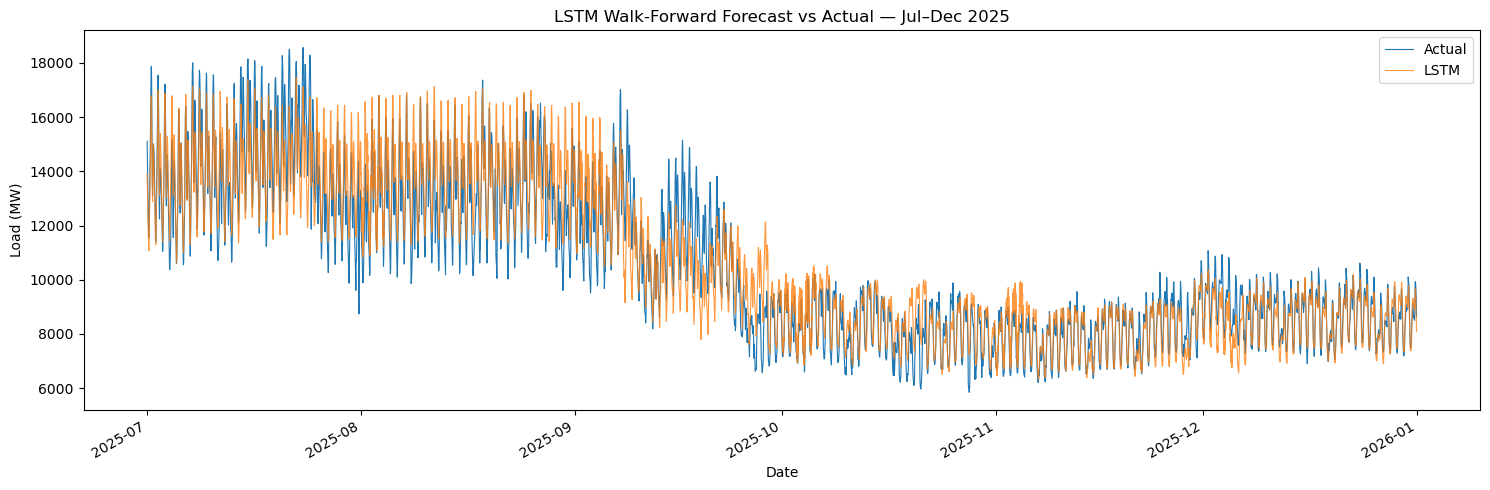

In [6]:

feature_cols = [
    'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_std_24',
    'rolling_mean_48', 'rolling_std_48',
    'rolling_mean_168', 'rolling_std_168',
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'hour', 'day_of_week', 'month', 'year'
]
target_col = 'load'
SEQ_LEN    = 168

# ── 1. Model ──────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=128,
                 num_layers=2, dropout=0.2, output_size=168):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# ── 2. Sequence builder ───────────────────────────────────────
def make_sequences(data_x, data_y, seq_len=168):
    X, y = [], []
    for i in range(len(data_x) - seq_len - 167):
        X.append(data_x[i : i + seq_len])
        y.append(data_y[i + seq_len : i + seq_len + 168])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# ── 3. Training function ──────────────────────────────────────
def train_lstm(X_tr, y_tr, input_size, epochs=50, batch_size=64):
    model     = LSTMForecaster(input_size=input_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_tr), torch.tensor(y_tr)
    )
    loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=False
    )

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs} — loss: {total_loss/len(loader):.4f}")
    return model

# ── 4. Walk-forward: monthly refit, weekly forecast ───────────
month_origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_lstm   = []
actuals_lstm = []

for i, month_origin in enumerate(month_origins):
    print(f"\n{'='*50}")
    print(f"Monthly refit {i+1}/6 — {month_origin.date()}")

    # train on all data before this month
    train_df = df.loc[: month_origin - pd.Timedelta(hours=1)].dropna()

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    X_scaled = scaler_x.fit_transform(train_df[feature_cols].values)
    y_scaled = scaler_y.fit_transform(
        train_df[target_col].values.reshape(-1, 1)
    ).ravel()

    X_seq, y_seq = make_sequences(X_scaled, y_scaled)
    print(f"Training on {len(X_seq)} sequences...")
    model = train_lstm(X_seq, y_seq, input_size=len(feature_cols))

    # weekly forecast windows within this month
    month_end    = month_origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
    week_origins = pd.date_range(month_origin, month_end, freq="7D")

    model.eval()
    with torch.no_grad():
        for wo in week_origins:
            win_end = wo - pd.Timedelta(hours=1)
            win_start = wo - pd.Timedelta(hours=SEQ_LEN)

            window = df.loc[win_start : win_end]
            if len(window) < SEQ_LEN:
                print(f"  Skipping {wo.date()} — insufficient window")
                continue

            actual_week = df.loc[wo : wo + pd.Timedelta(hours=167), target_col]
            if len(actual_week) == 0:
                continue

            x_in = scaler_x.transform(window[feature_cols].values)
            x_in = torch.tensor(x_in[np.newaxis], dtype=torch.float32).to(device)

            pred_scaled = model(x_in).cpu().numpy().ravel()
            pred_mw     = scaler_y.inverse_transform(
                pred_scaled.reshape(-1, 1)
            ).ravel()

            pred_series = pd.Series(
                pred_mw[:len(actual_week)],
                index=actual_week.index
            )

            preds_lstm.append(pred_series)
            actuals_lstm.append(actual_week)
            print(f"  Week {wo.date()} forecasted — {len(actual_week)} hours")

# ── 5. Metrics ────────────────────────────────────────────────
pred_lstm   = pd.concat(preds_lstm).sort_index()
actual_lstm = pd.concat(actuals_lstm).sort_index()

mae  = np.mean(np.abs(actual_lstm - pred_lstm))
rmse = np.sqrt(np.mean((actual_lstm - pred_lstm)**2))
mape = np.mean(np.abs((actual_lstm - pred_lstm) / actual_lstm)) * 100

print(f"\nLSTM Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ── 6. Plot ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_lstm.index, actual_lstm.values, label='Actual', linewidth=0.8)
ax.plot(pred_lstm.index, pred_lstm.values, label='LSTM', linewidth=0.8, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.set_title('LSTM Walk-Forward Forecast vs Actual — Jul–Dec 2025')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()